# Análisis Exploratorio de Datos (EDA) Agrícola: Análisis Municipio a Municipio y sus Varios Cultivos (2015-2024)

**Departamento:** Valle del Cauca  
**Enfoque Estructural:** El análisis se efectúa **municipio a municipio**, y **dentro de cada municipio se examinan sus varios cultivos** mediante subplots e identificadores visuales individuales.  
**Cálculos de Rentabilidad y Depuración:**  
- **Valor Venta Estimado:** $\text{valor\_venta} = (\text{produccion\_toneladas} \times 1,000) \times \text{precio\_promedio\_anual\_sipsa}$ ($\text{COP}$).  
- **Filtro de Rendimiento:** $0 < \text{Rendimiento} \le 100\text{ Ton}/\text{Ha}$ para depurar ceros y distorsiones atípicas.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

# Carga de datos
data_path = Path('../data/dataset_consolidado_valle.csv')
if not data_path.exists():
    data_path = Path('data/dataset_consolidado_valle.csv')

df_raw = pd.read_csv(data_path)
num_cols = ['hectareas_sembradas', 'hectareas_cosechadas', 'produccion_toneladas', 'rendimiento_toneladas_ha', 'precio_promedio_anual_sipsa', 'promedio_oni']
for col in num_cols:
    df_raw[col] = pd.to_numeric(df_raw[col].astype(str).str.replace(',', '.'), errors='coerce')

df = df_raw[df_raw['anio'] >= 2015].copy()

# Estandarización de grupos
df['tipo_cultivo_clean'] = df['tipo_cultivo'].astype(str).str.strip().str.title()
mapping_grupos = {
    'Cultivos Tropicales Tradicionales': 'Tropicales Tradicionales',
    'Cultivos Tropicales Tradicionales ': 'Tropicales Tradicionales',
    'Raíces Y Tubérculos': 'Raíces y Tubérculos',
    'Cultivos Para Condimentos Y Bebidas Medicinales Y Aromáticas': 'Aromáticas y Medicinales',
    'Cultivos Para Condimentos, Bebidas Medicinales Y Aromáticas': 'Aromáticas y Medicinales',
}
df['grupo_cultivo'] = df['tipo_cultivo_clean'].replace(mapping_grupos)

df['kilos_cosechados'] = df['produccion_toneladas'] * 1000.0
df['valor_venta'] = df['kilos_cosechados'] * df['precio_promedio_anual_sipsa']
df['valor_venta_millones'] = df['valor_venta'] / 1e6

print(f"Dataset cargado (2015-2024). Registros totales: {len(df):,}")
print(f"Registros con Valor Venta (Precios SIPSA válidos): {df['valor_venta'].notnull().sum():,}")
print(f"Municipios evaluados: {df['municipio'].nunique()} | Cultivos evaluados: {df['cultivo'].nunique()}")

## 1. Valor de Venta Estimado por Municipio y sus Varios Cultivos

Analizamos las parejas `(municipio - cultivo)` líderes en generación de ingreso bruto acumulado ($COP$).

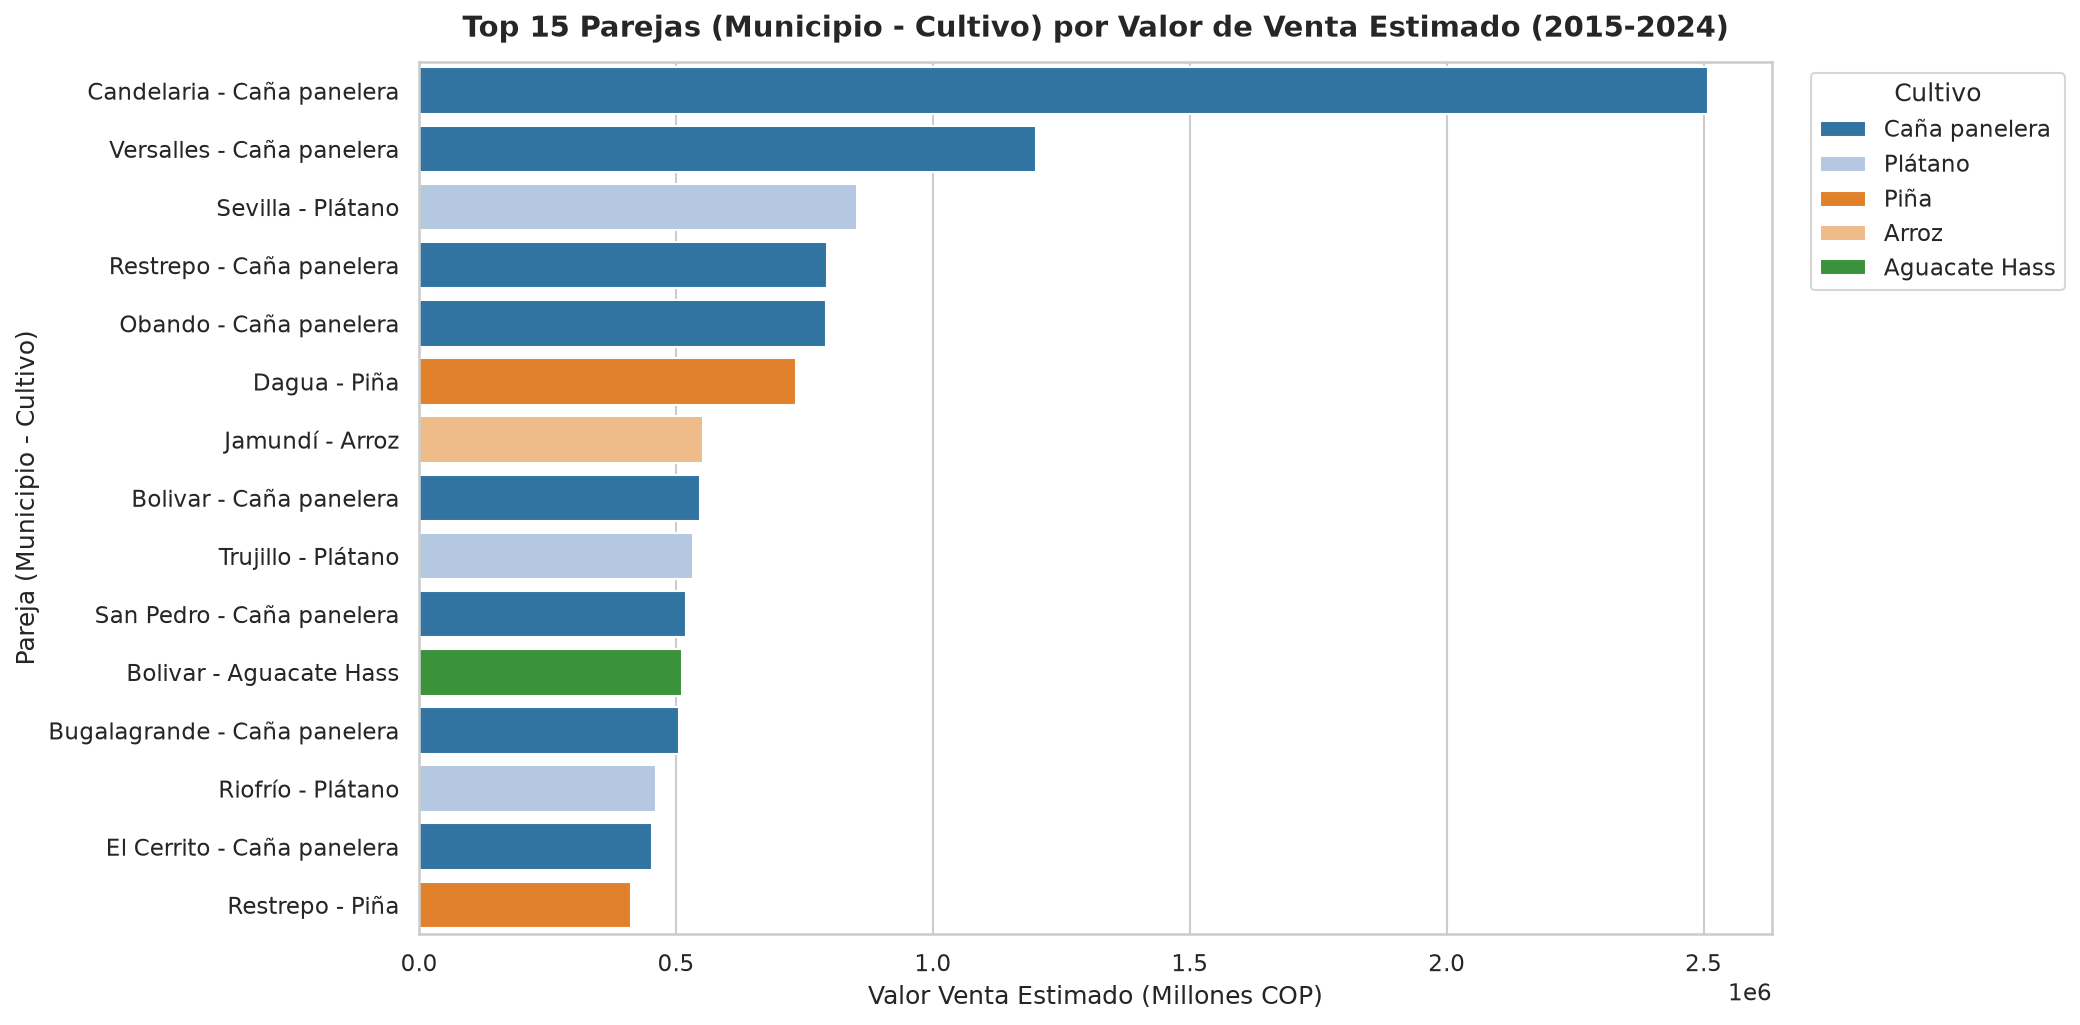

In [1]:
resumen_mun_prod = df.groupby(['municipio', 'cultivo', 'grupo_cultivo']).agg(
    anios_registrados=('anio', 'count'),
    total_hectareas_cosechadas=('hectareas_cosechadas', 'sum'),
    total_produccion_toneladas=('produccion_toneladas', 'sum'),
    total_kilos_cosechados=('kilos_cosechados', 'sum'),
    rendimiento_promedio_ton_ha=('rendimiento_toneladas_ha', 'mean'),
    precio_promedio_sipsa=('precio_promedio_anual_sipsa', 'mean'),
    total_valor_venta_millones=('valor_venta_millones', 'sum')
).reset_index()

top_ingreso = resumen_mun_prod.dropna(subset=['precio_promedio_sipsa']).sort_values('total_valor_venta_millones', ascending=False).head(15).copy()
top_ingreso['mun_cultivo'] = top_ingreso['municipio'] + ' - ' + top_ingreso['cultivo']

plt.figure(figsize=(14, 7))
sns.barplot(data=top_ingreso, x='total_valor_venta_millones', y='mun_cultivo', hue='cultivo', dodge=False, palette="tab20")
plt.title('Top 15 Parejas (Municipio - Cultivo) por Valor de Venta Estimado (2015-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Valor Venta Estimado (Millones COP)', fontsize=12)
plt.ylabel('Pareja (Municipio - Cultivo)', fontsize=12)
plt.legend(title='Cultivo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("--- Top 10 Parejas (Municipio - Cultivo) por Valor Venta Estimado ---")
top_ingreso[['municipio', 'cultivo', 'grupo_cultivo', 'total_kilos_cosechados', 'precio_promedio_sipsa', 'total_valor_venta_millones']].head(10)

## 2. Diagramas de Dispersión Municipio a Municipio: Análisis por Municipio de sus Varios Cultivos

Evaluamos municipio a municipio (en subplots independientes por cada territorio) las relaciones de **Kilos Cosechados vs. Valor Venta** y **Rendimiento (Ton/Ha) vs. Precio SIPSA ($/Kg)** para sus distintos cultivos.

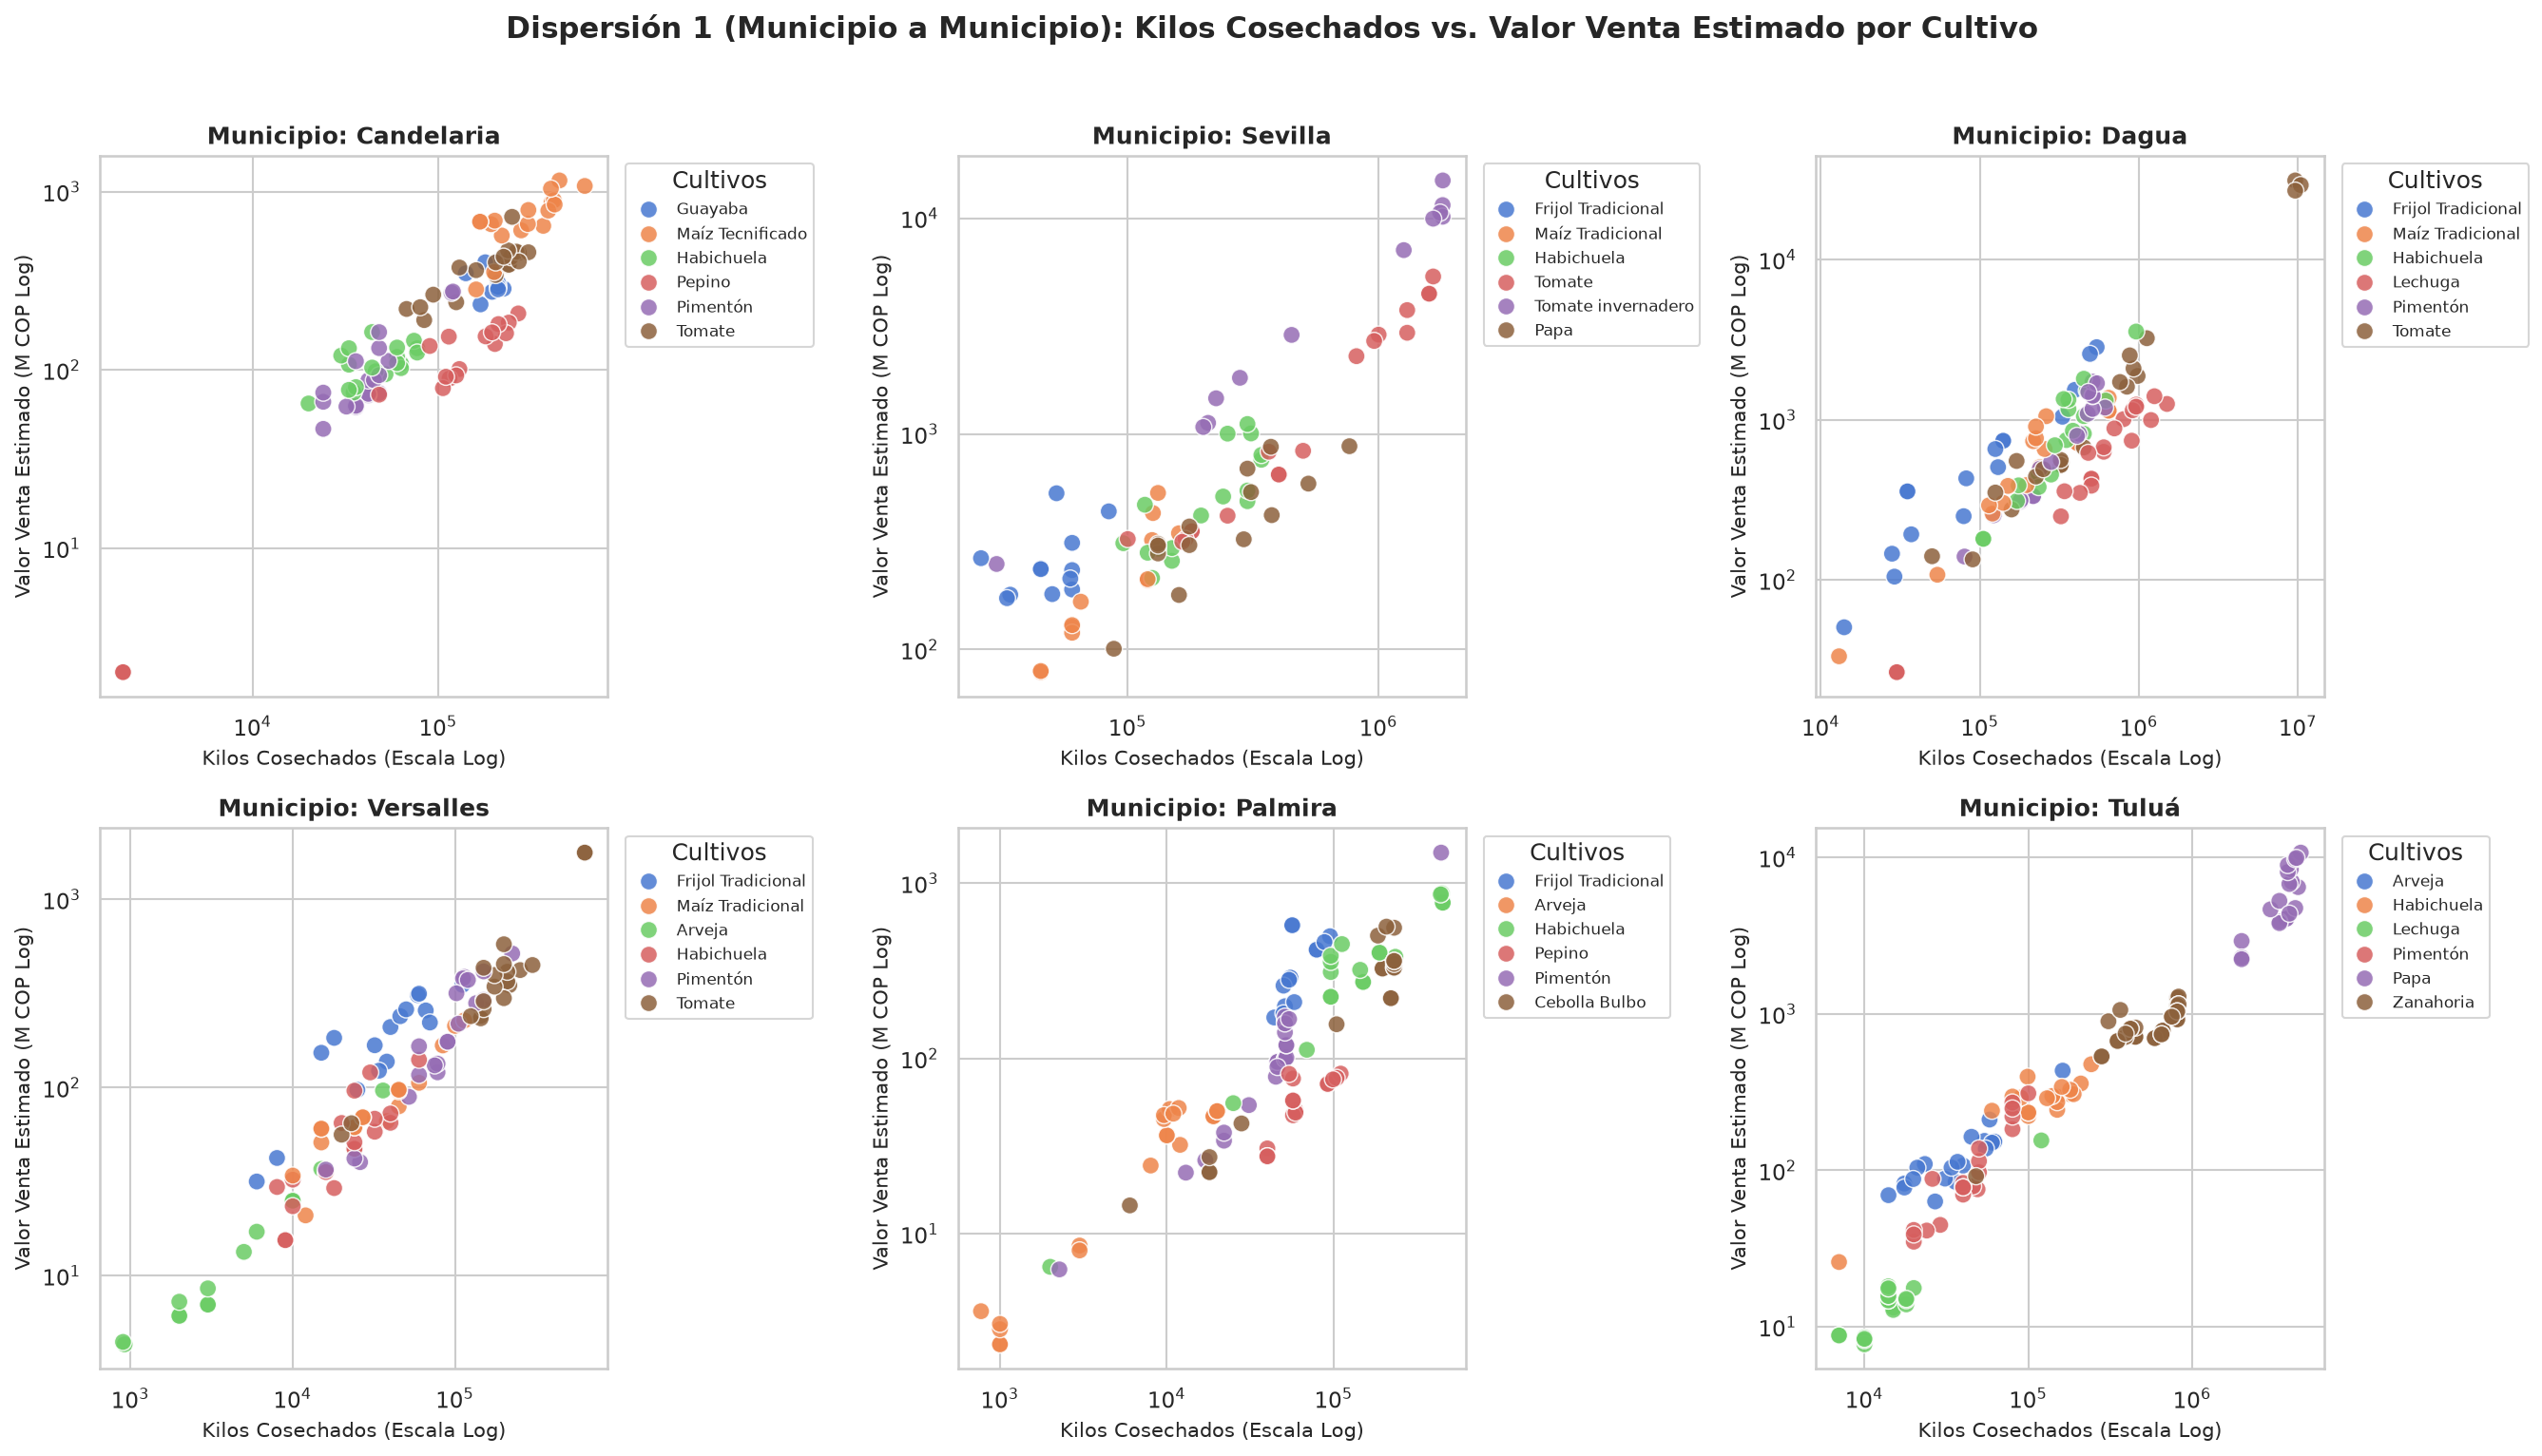

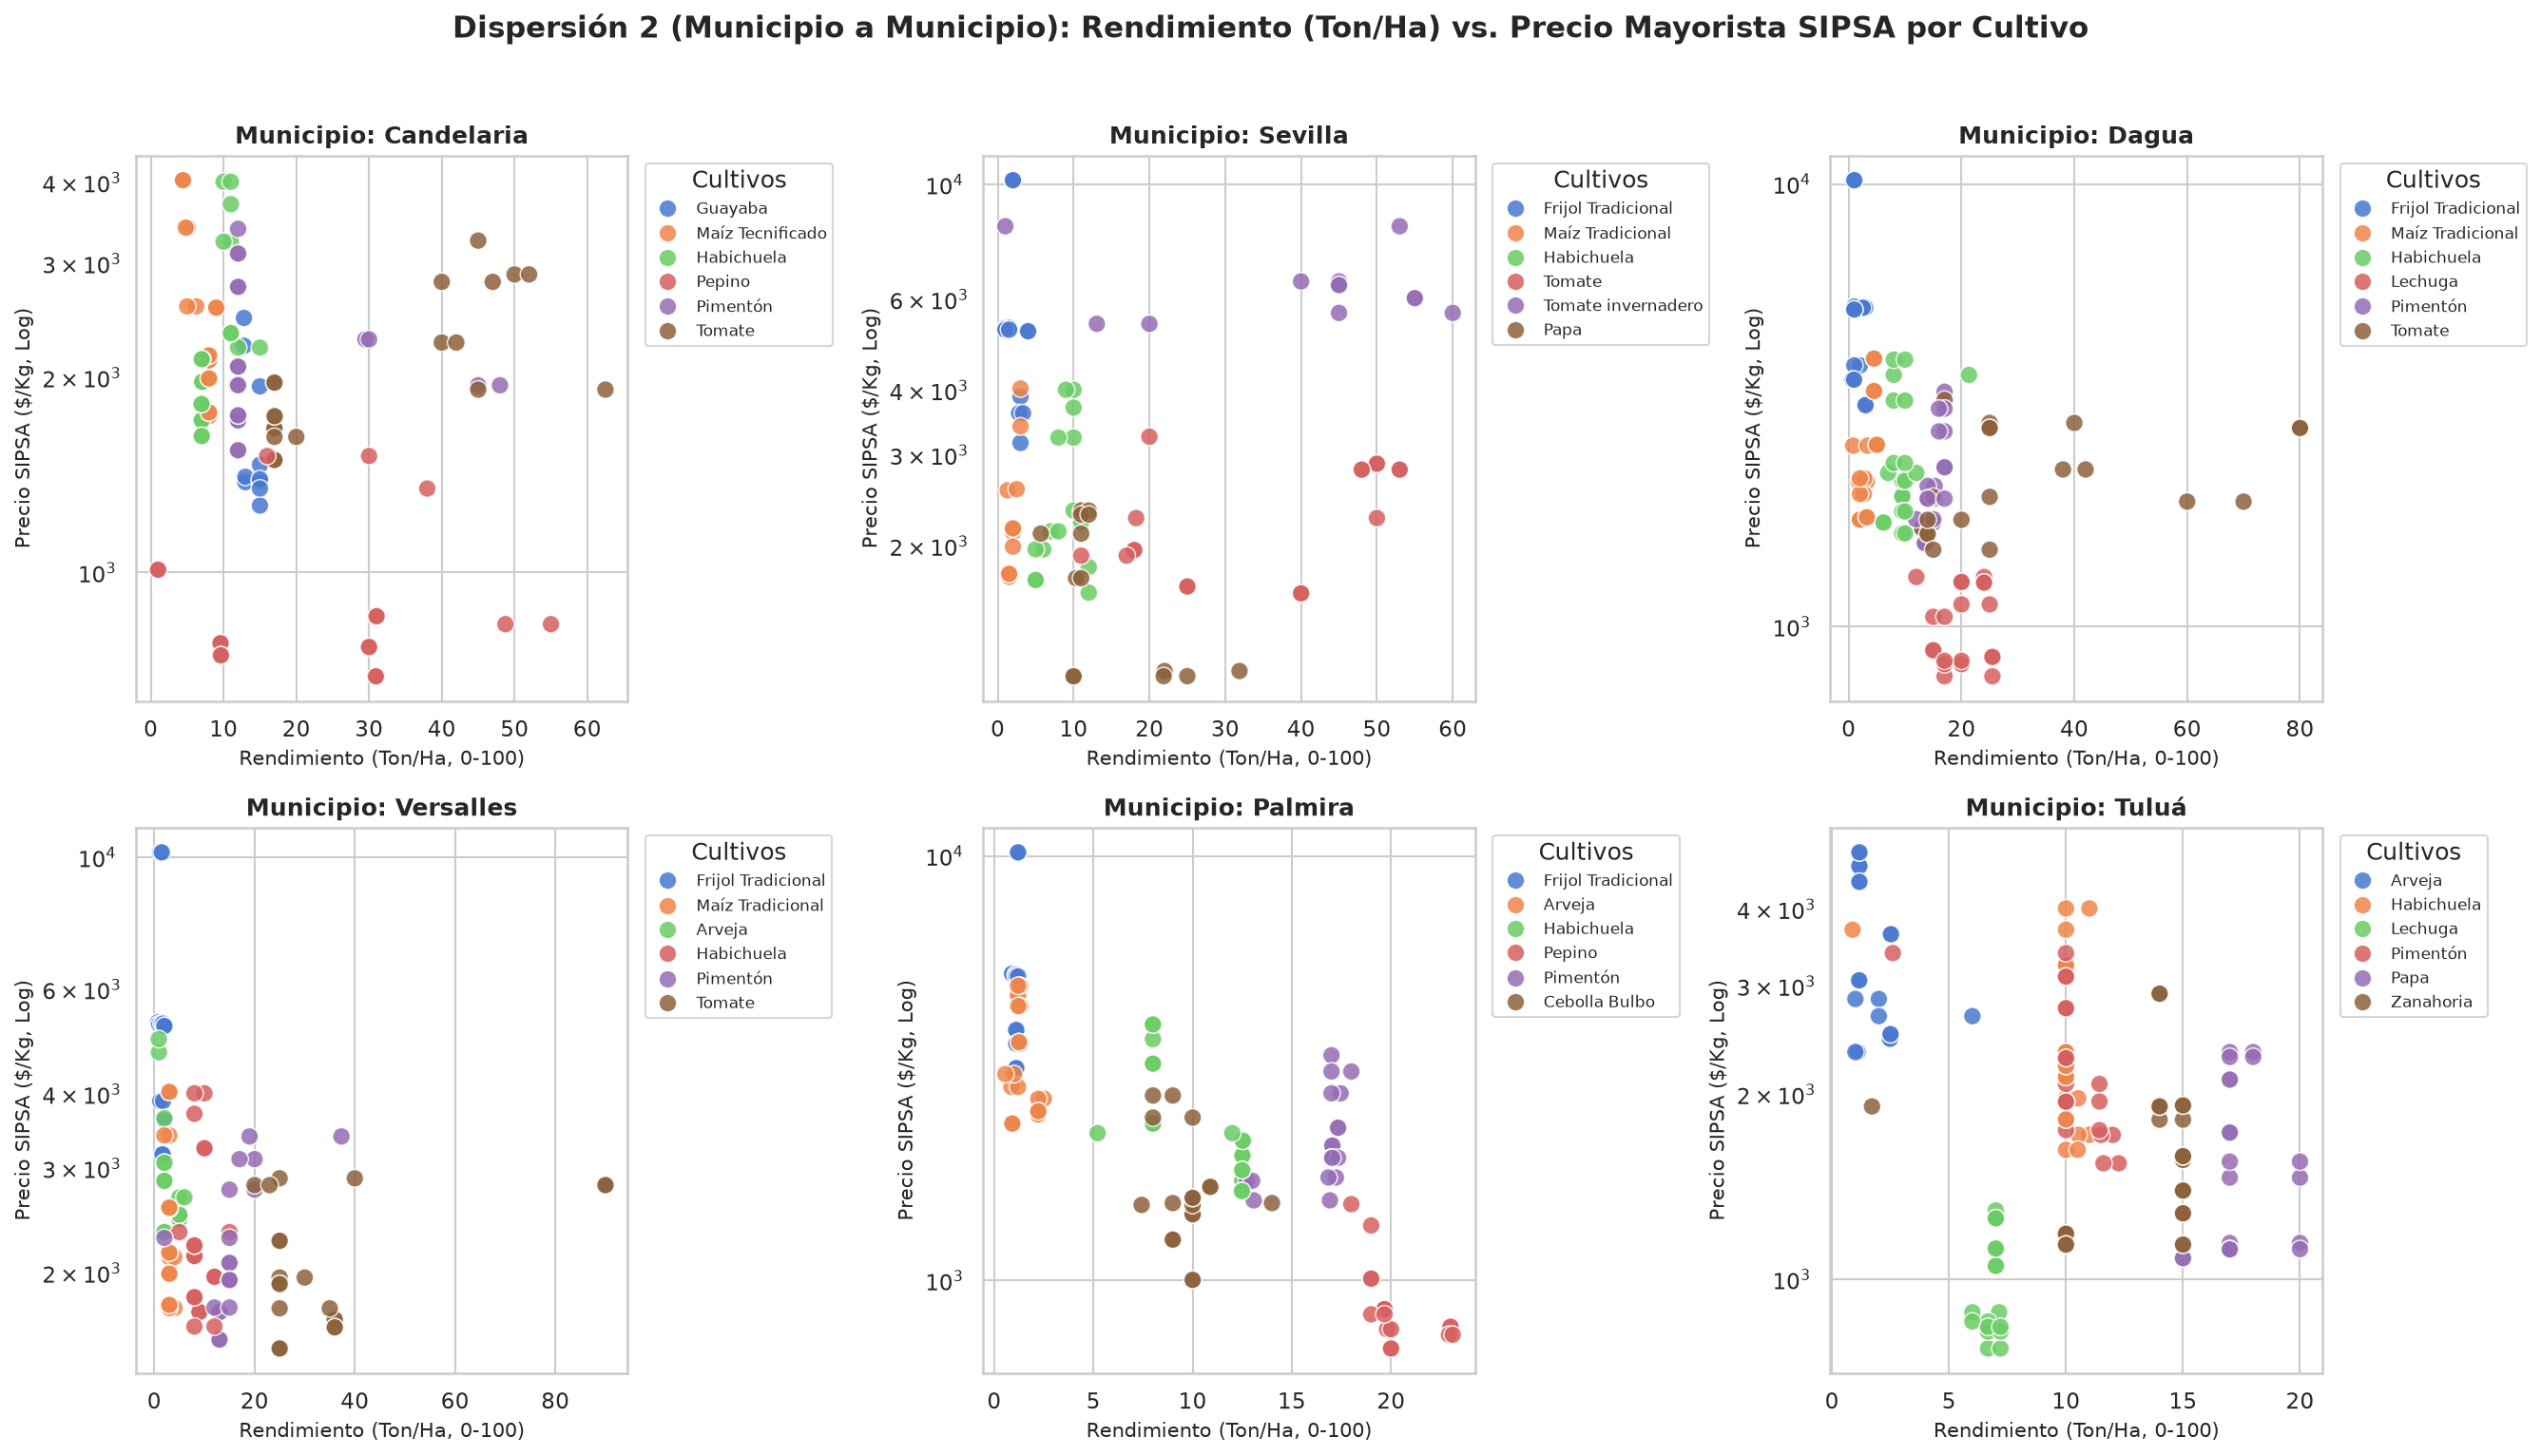

In [1]:
muns_principales = ['Candelaria', 'Sevilla', 'Dagua', 'Versalles', 'Palmira', 'Tuluá']
df_val = df[(df['kilos_cosechados'] > 0) & (df['valor_venta_millones'] > 0)].dropna(subset=['valor_venta_millones'])
df_rend_val = df[(df['rendimiento_toneladas_ha'] > 0) & (df['rendimiento_toneladas_ha'] <= 100)].dropna(subset=['precio_promedio_anual_sipsa'])

# Dispersión 1 Municipio a Municipio: Kilos vs Valor Venta por Cultivo
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, mun in enumerate(muns_principales):
    df_m = df_val[df_val['municipio'] == mun]
    top_c = df_m['cultivo'].value_counts().head(6).index.tolist()
    sns.scatterplot(ax=axes[idx], data=df_m[df_m['cultivo'].isin(top_c)], x='kilos_cosechados', y='valor_venta_millones', hue='cultivo', alpha=0.85, s=75)
    axes[idx].set_title(f'Municipio: {mun}', fontsize=12, fontweight='bold')
    axes[idx].set_xscale('log')
    axes[idx].set_yscale('log')
    axes[idx].set_xlabel('Kilos Cosechados (Log)', fontsize=10)
    axes[idx].set_ylabel('Valor Venta Estimado (M COP Log)', fontsize=10)
    axes[idx].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Cultivos')
plt.suptitle('Dispersión 1 (Municipio a Municipio): Kilos Cosechados vs. Valor Venta Estimado por Cultivo', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Dispersión 2 Municipio a Municipio: Rendimiento vs Precio SIPSA por Cultivo
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, mun in enumerate(muns_principales):
    df_m = df_rend_val[df_rend_val['municipio'] == mun]
    top_c = df_m['cultivo'].value_counts().head(6).index.tolist()
    sns.scatterplot(ax=axes[idx], data=df_m[df_m['cultivo'].isin(top_c)], x='rendimiento_toneladas_ha', y='precio_promedio_anual_sipsa', hue='cultivo', alpha=0.85, s=80)
    axes[idx].set_title(f'Municipio: {mun}', fontsize=12, fontweight='bold')
    axes[idx].set_yscale('log')
    axes[idx].set_xlabel('Rendimiento (Ton/Ha, 0-100)', fontsize=10)
    axes[idx].set_ylabel('Precio SIPSA ($/Kg, Log)', fontsize=10)
    axes[idx].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Cultivos')
plt.suptitle('Dispersión 2 (Municipio a Municipio): Rendimiento (Ton/Ha) vs. Precio Mayorista SIPSA por Cultivo', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Diagramas de Dispersión Municipio a Municipio: Hectáreas Cosechadas e Índice Climático ONI

Analizamos dentro de cada municipio el comportamientos de las hectáreas cosechadas y el efecto del índice climático ONI sobre los varios cultivos de ese territorio.

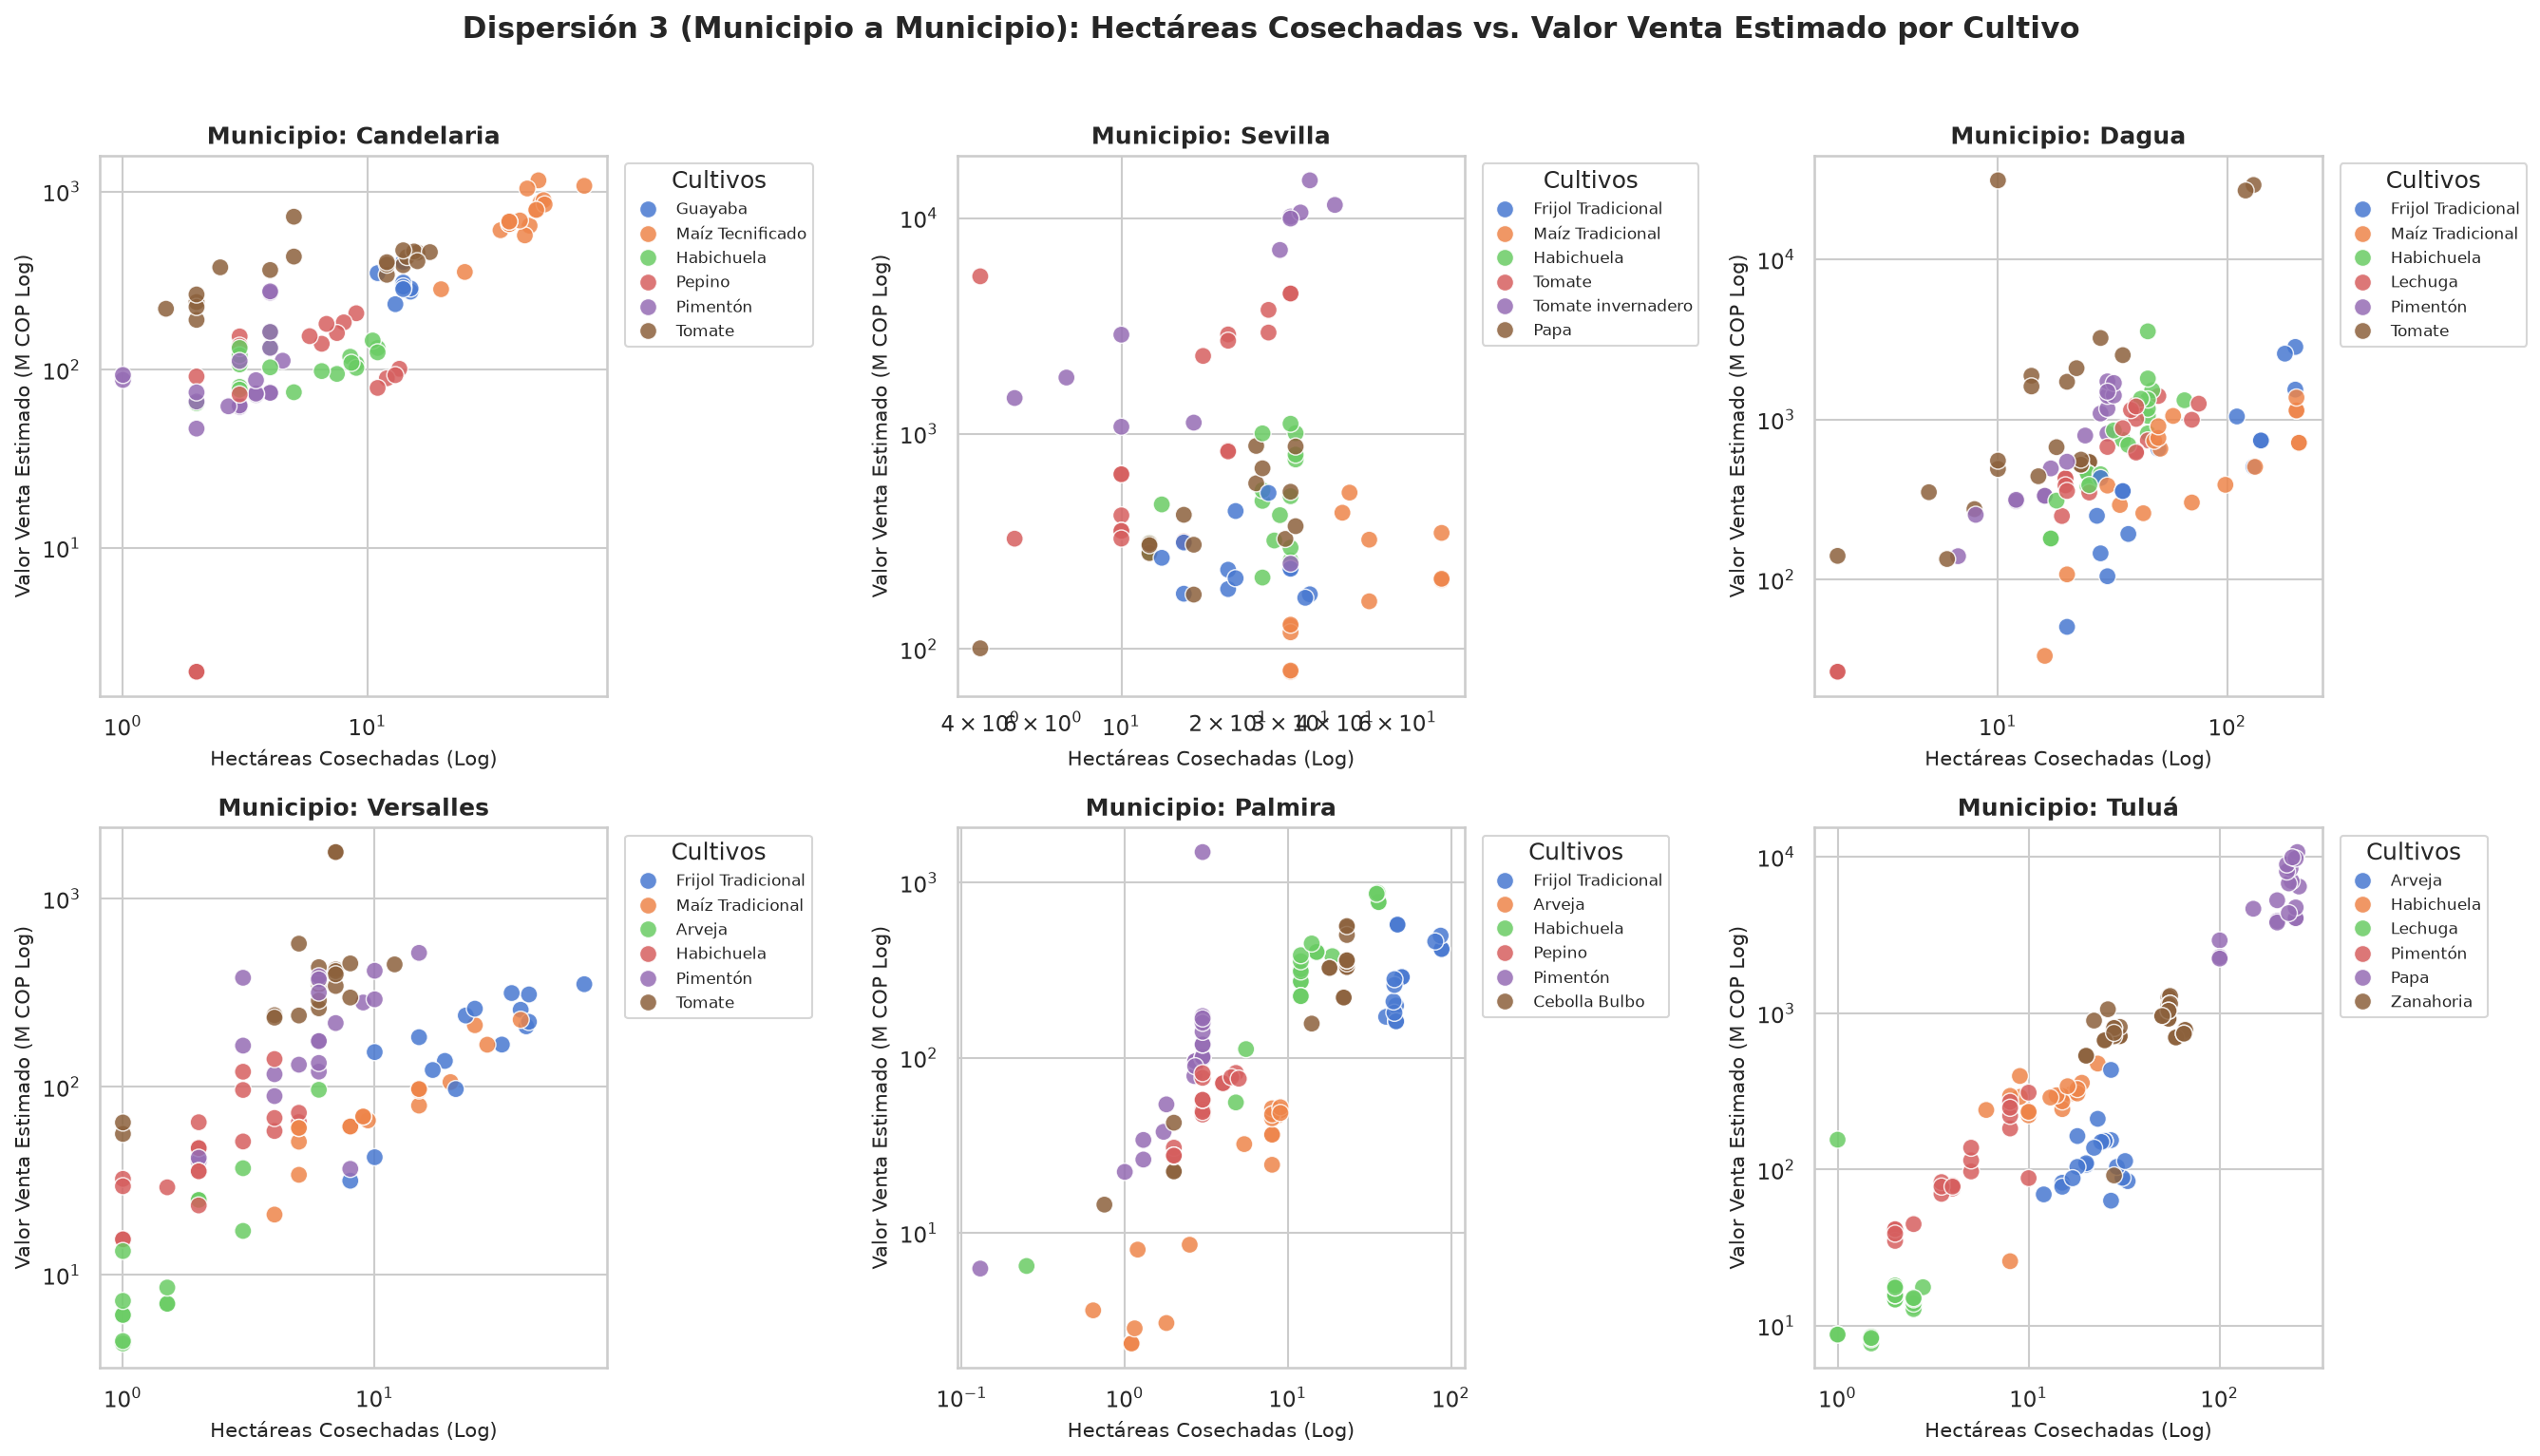

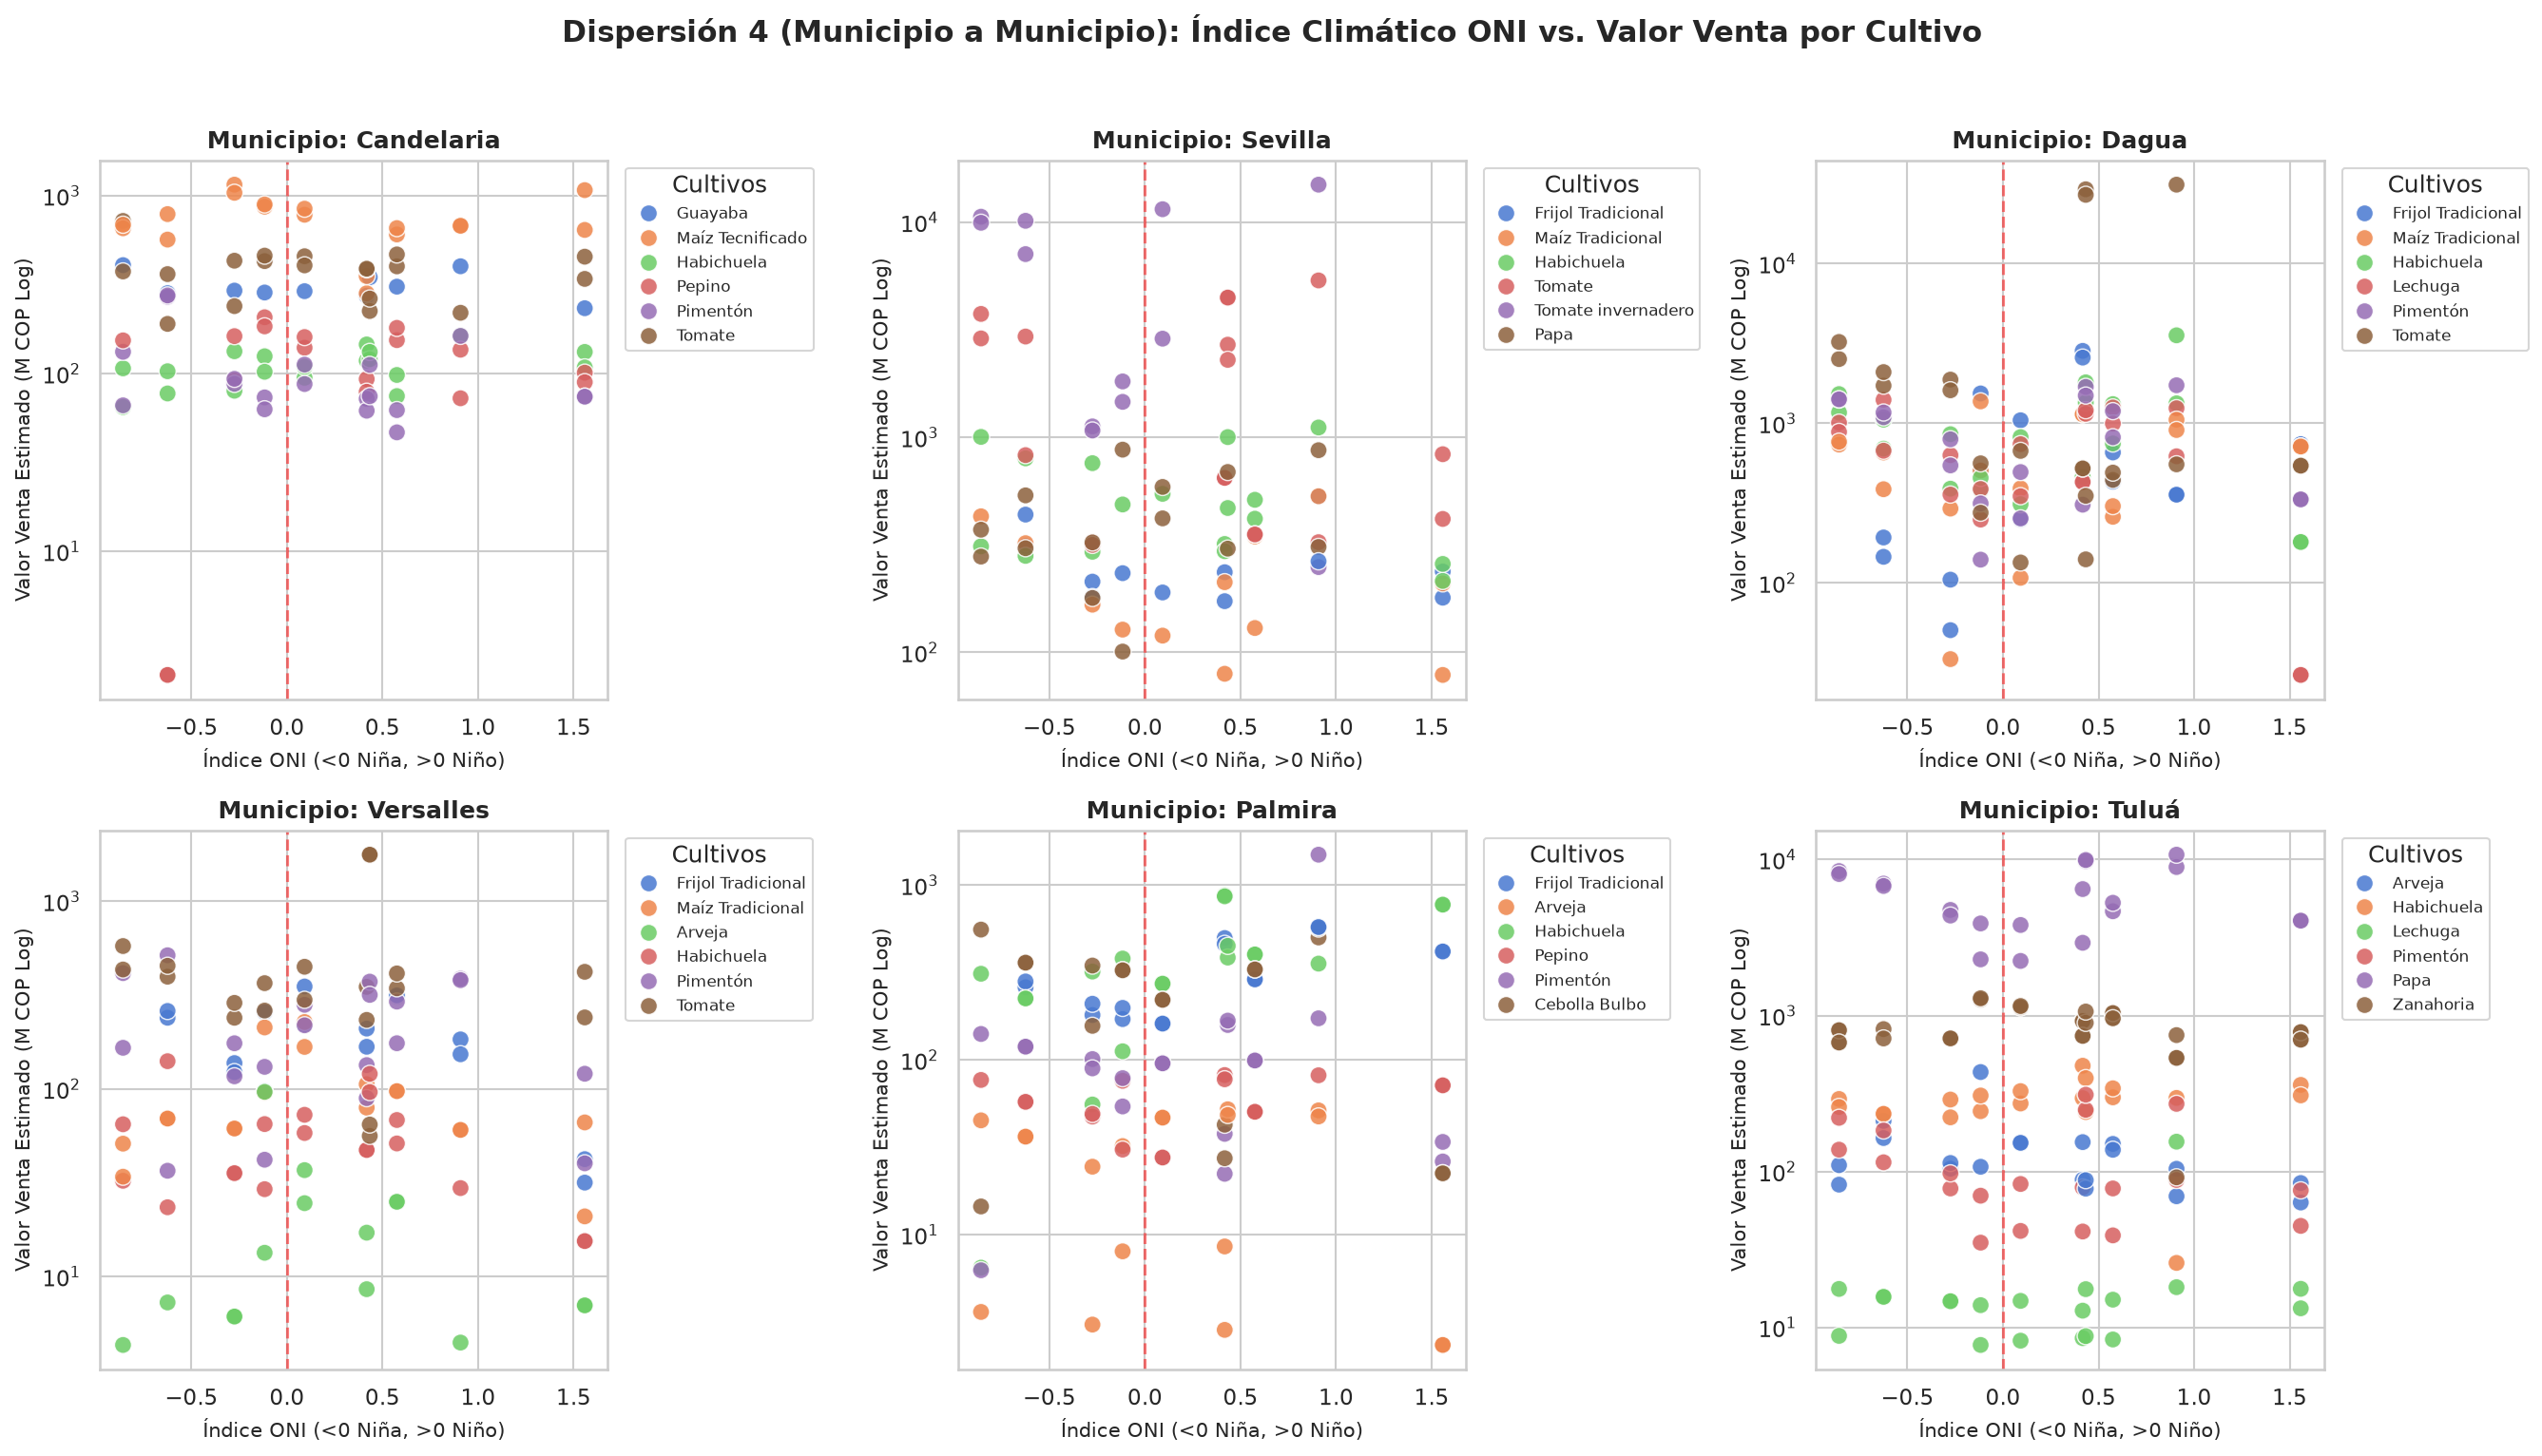

In [1]:
# Dispersión 3 Municipio a Municipio: Hectáreas vs Valor Venta por Cultivo
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, mun in enumerate(muns_principales):
    df_m = df_val[df_val['municipio'] == mun]
    top_c = df_m['cultivo'].value_counts().head(6).index.tolist()
    sns.scatterplot(ax=axes[idx], data=df_m[df_m['cultivo'].isin(top_c)], x='hectareas_cosechadas', y='valor_venta_millones', hue='cultivo', alpha=0.85, s=75)
    axes[idx].set_title(f'Municipio: {mun}', fontsize=12, fontweight='bold')
    axes[idx].set_xscale('log')
    axes[idx].set_yscale('log')
    axes[idx].set_xlabel('Hectáreas Cosechadas (Log)', fontsize=10)
    axes[idx].set_ylabel('Valor Venta Estimado (M COP Log)', fontsize=10)
    axes[idx].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Cultivos')
plt.suptitle('Dispersión 3 (Municipio a Municipio): Hectáreas Cosechadas vs. Valor Venta por Cultivo', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Dispersión 4 Municipio a Municipio: ONI vs Valor Venta por Cultivo
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, mun in enumerate(muns_principales):
    df_m = df_val[df_val['municipio'] == mun]
    top_c = df_m['cultivo'].value_counts().head(6).index.tolist()
    sns.scatterplot(ax=axes[idx], data=df_m[df_m['cultivo'].isin(top_c)], x='promedio_oni', y='valor_venta_millones', hue='cultivo', alpha=0.85, s=75)
    axes[idx].axvline(0, color='red', linestyle='--', alpha=0.5)
    axes[idx].set_title(f'Municipio: {mun}', fontsize=12, fontweight='bold')
    axes[idx].set_yscale('log')
    axes[idx].set_xlabel('Índice ONI (<0 Niña, >0 Niño)', fontsize=10)
    axes[idx].set_ylabel('Valor Venta Estimado (M COP Log)', fontsize=10)
    axes[idx].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Cultivos')
plt.suptitle('Dispersión 4 (Municipio a Municipio): Índice Climático ONI vs. Valor Venta por Cultivo', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Sensibilidad Climática ONI Municipio a Municipio: Rendimiento Agrícola (Ton/Ha) por Cultivo

Evaluamos dentro de cada municipio el rendimiento de sus distintos cultivos frente a variaciones climáticas ONI (El Niño, La Niña y Neutro).

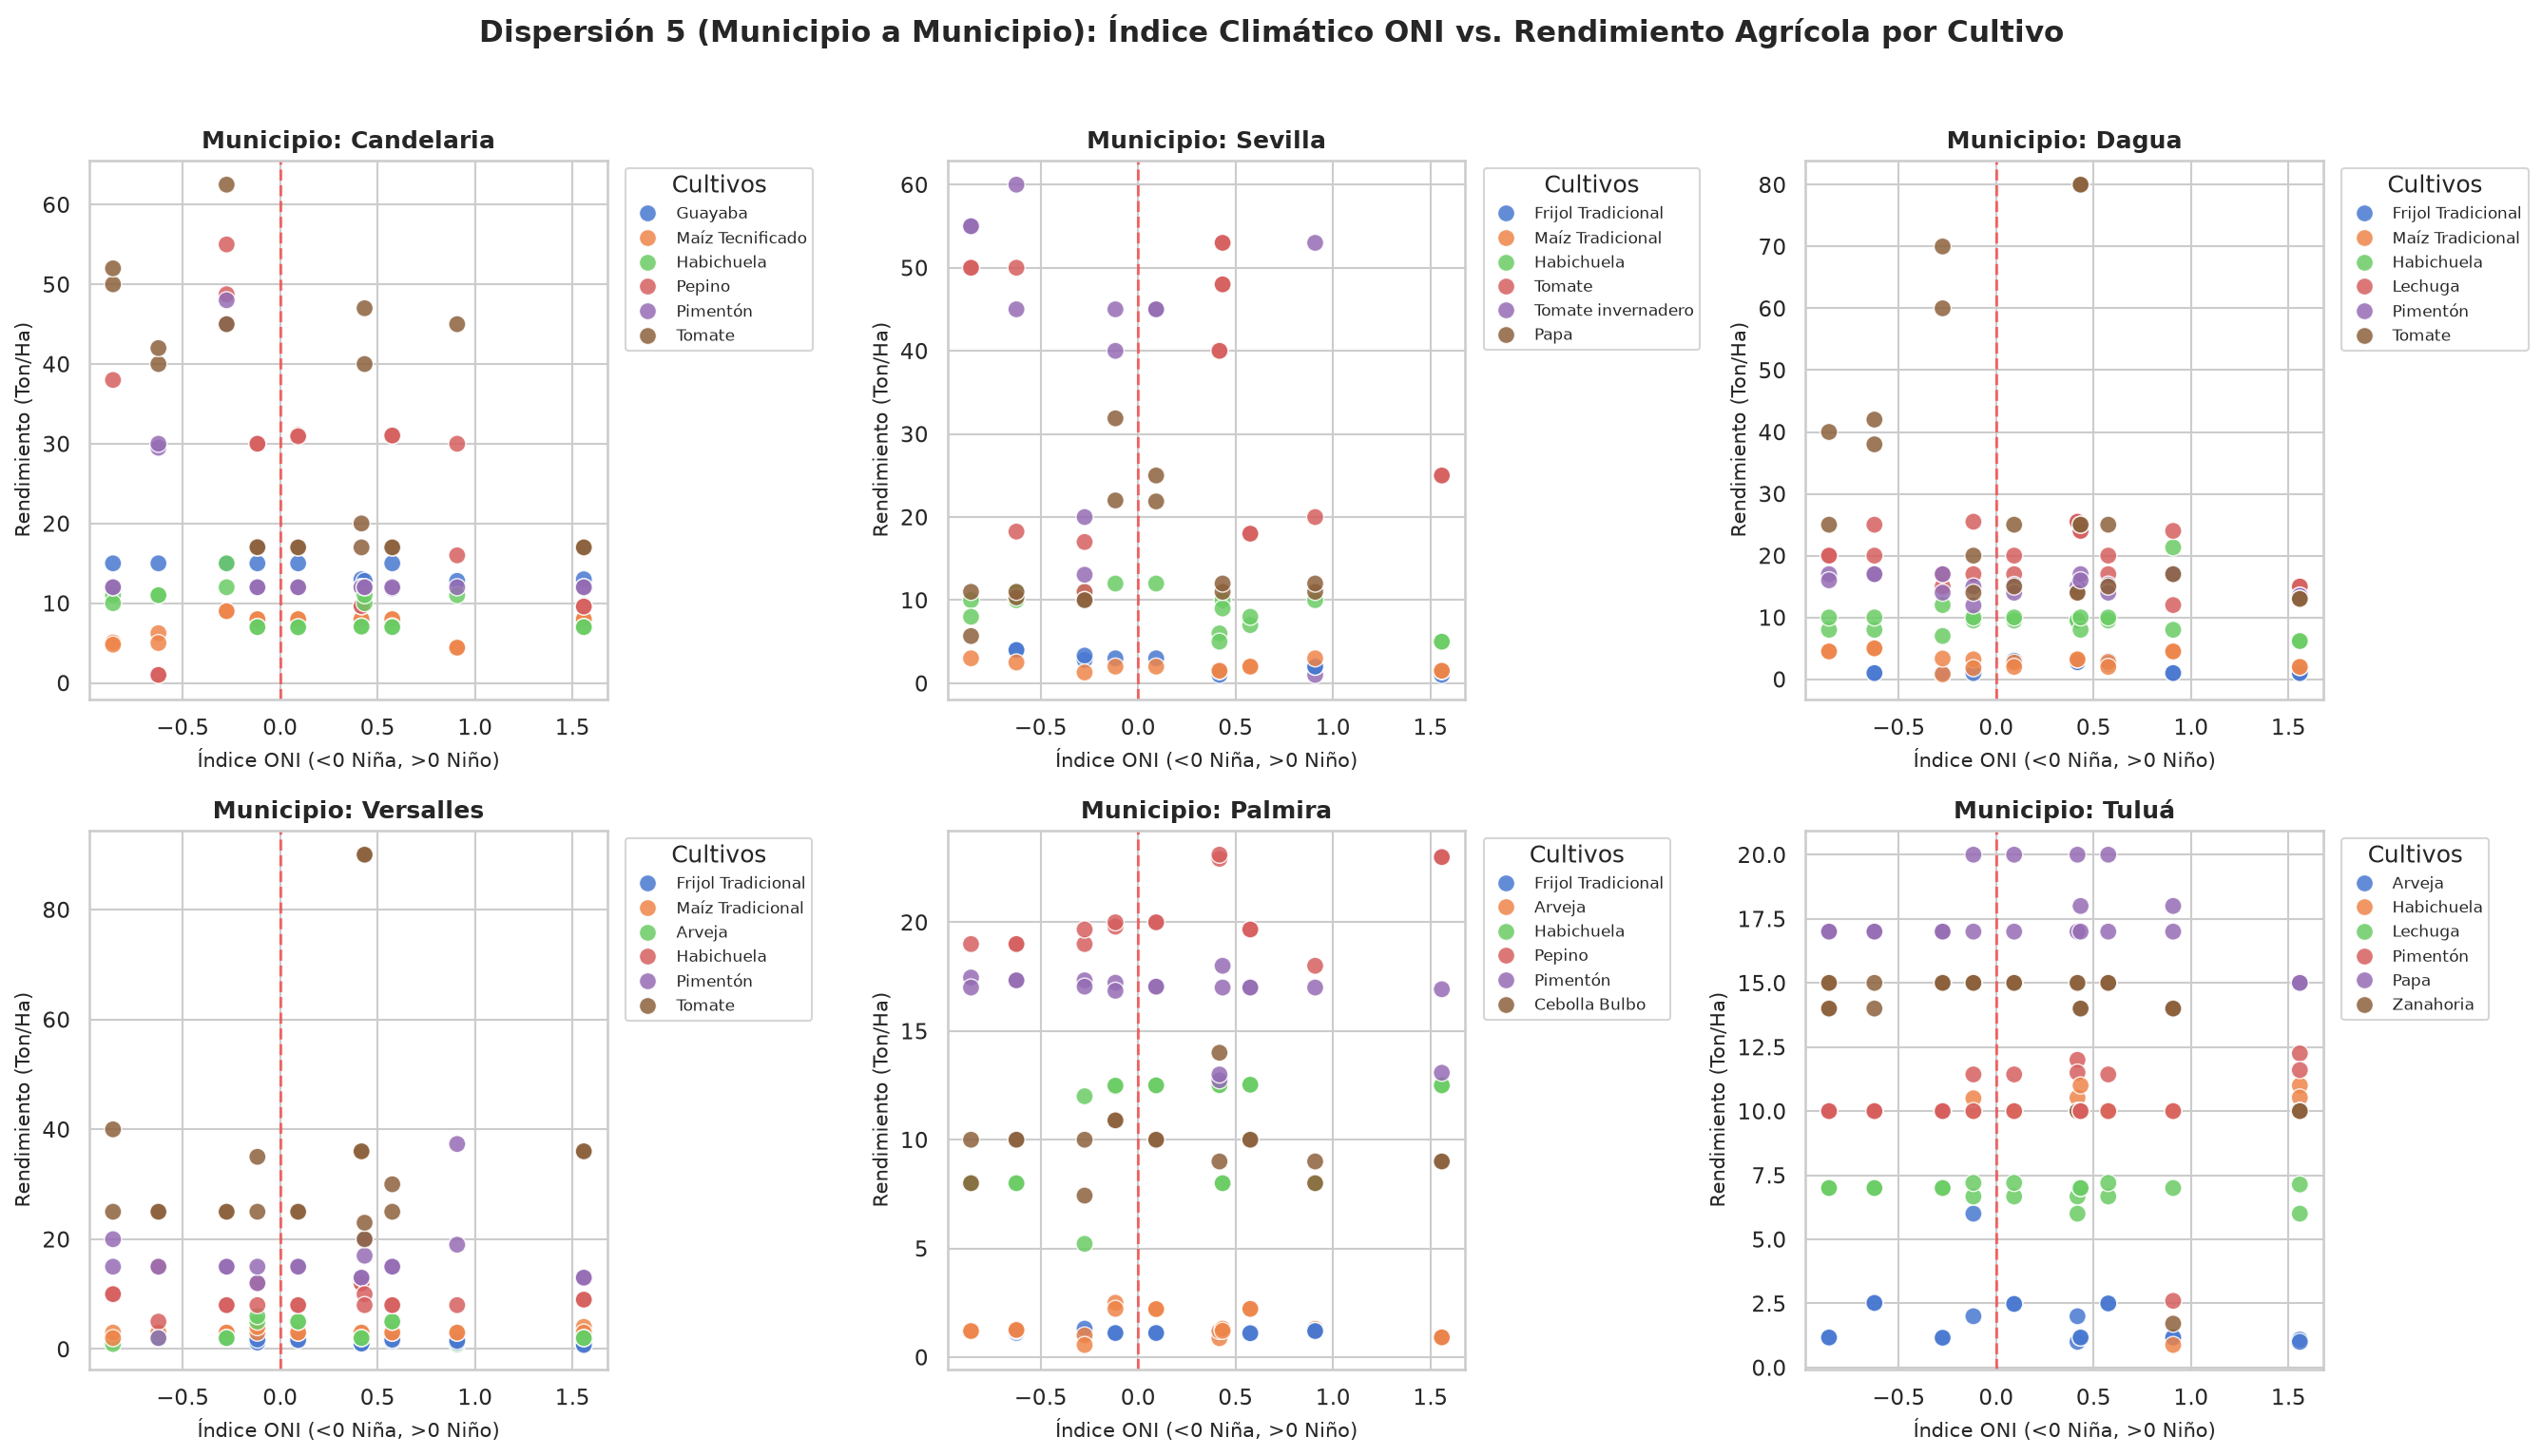

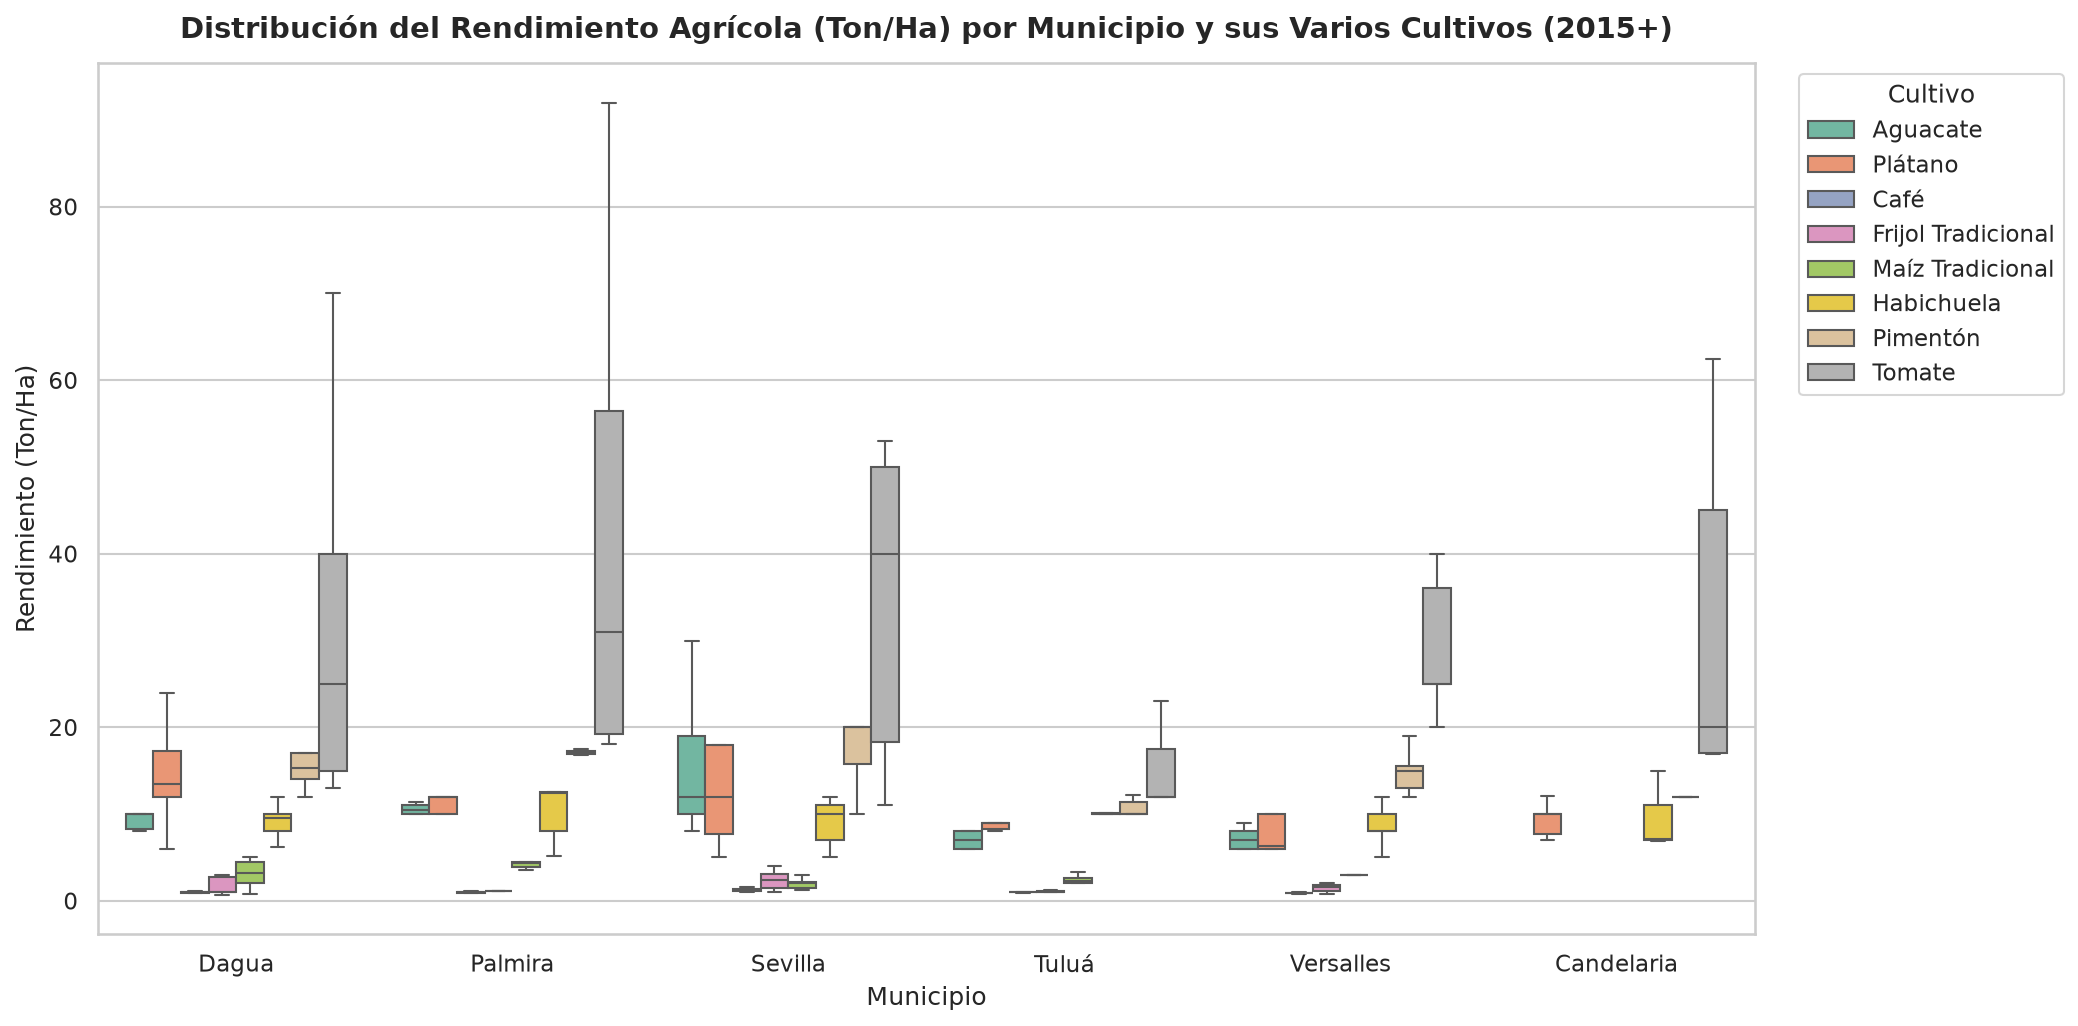

In [1]:
# Dispersión 5 Municipio a Municipio: ONI vs Rendimiento (Ton/Ha) por Cultivo
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, mun in enumerate(muns_principales):
    df_m = df_rend_val[df_rend_val['municipio'] == mun]
    top_c = df_m['cultivo'].value_counts().head(6).index.tolist()
    sns.scatterplot(ax=axes[idx], data=df_m[df_m['cultivo'].isin(top_c)], x='promedio_oni', y='rendimiento_toneladas_ha', hue='cultivo', alpha=0.85, s=75)
    axes[idx].axvline(0, color='red', linestyle='--', alpha=0.5)
    axes[idx].set_title(f'Municipio: {mun}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Índice ONI (<0 Niña, >0 Niño)', fontsize=10)
    axes[idx].set_ylabel('Rendimiento (Ton/Ha)', fontsize=10)
    axes[idx].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Cultivos')
plt.suptitle('Dispersión 5 (Municipio a Municipio): Índice ONI vs. Rendimiento por Cultivo', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Boxplot por Municipio y sus Varios Cultivos
plt.figure(figsize=(14, 7))
top_8_cultivos = ['Tomate', 'Habichuela', 'Plátano', 'Aguacate', 'Pimentón', 'Café', 'Frijol Tradicional', 'Maíz Tradicional']
df_box_sub = df_rend_val[df_rend_val['municipio'].isin(muns_principales) & df_rend_val['cultivo'].isin(top_8_cultivos)]
sns.boxplot(data=df_box_sub, x='municipio', y='rendimiento_toneladas_ha', hue='cultivo', palette="Set2", showfliers=False)
plt.title('Distribución del Rendimiento Agrícola (Ton/Ha) por Municipio y sus Varios Cultivos (2015+)', fontsize=14, fontweight='bold')
plt.xlabel('Municipio', fontsize=12)
plt.ylabel('Rendimiento (Ton/Ha)', fontsize=12)
plt.legend(title='Cultivo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. Matrices de Correlación Multivariable Municipio a Municipio

Analizamos las matrices de correlación interna para cada uno de los municipios agrícolas principales (Palmira, Tuluá, Candelaria, Sevilla), observando las dinámicas intervariables entre sus varios cultivos.

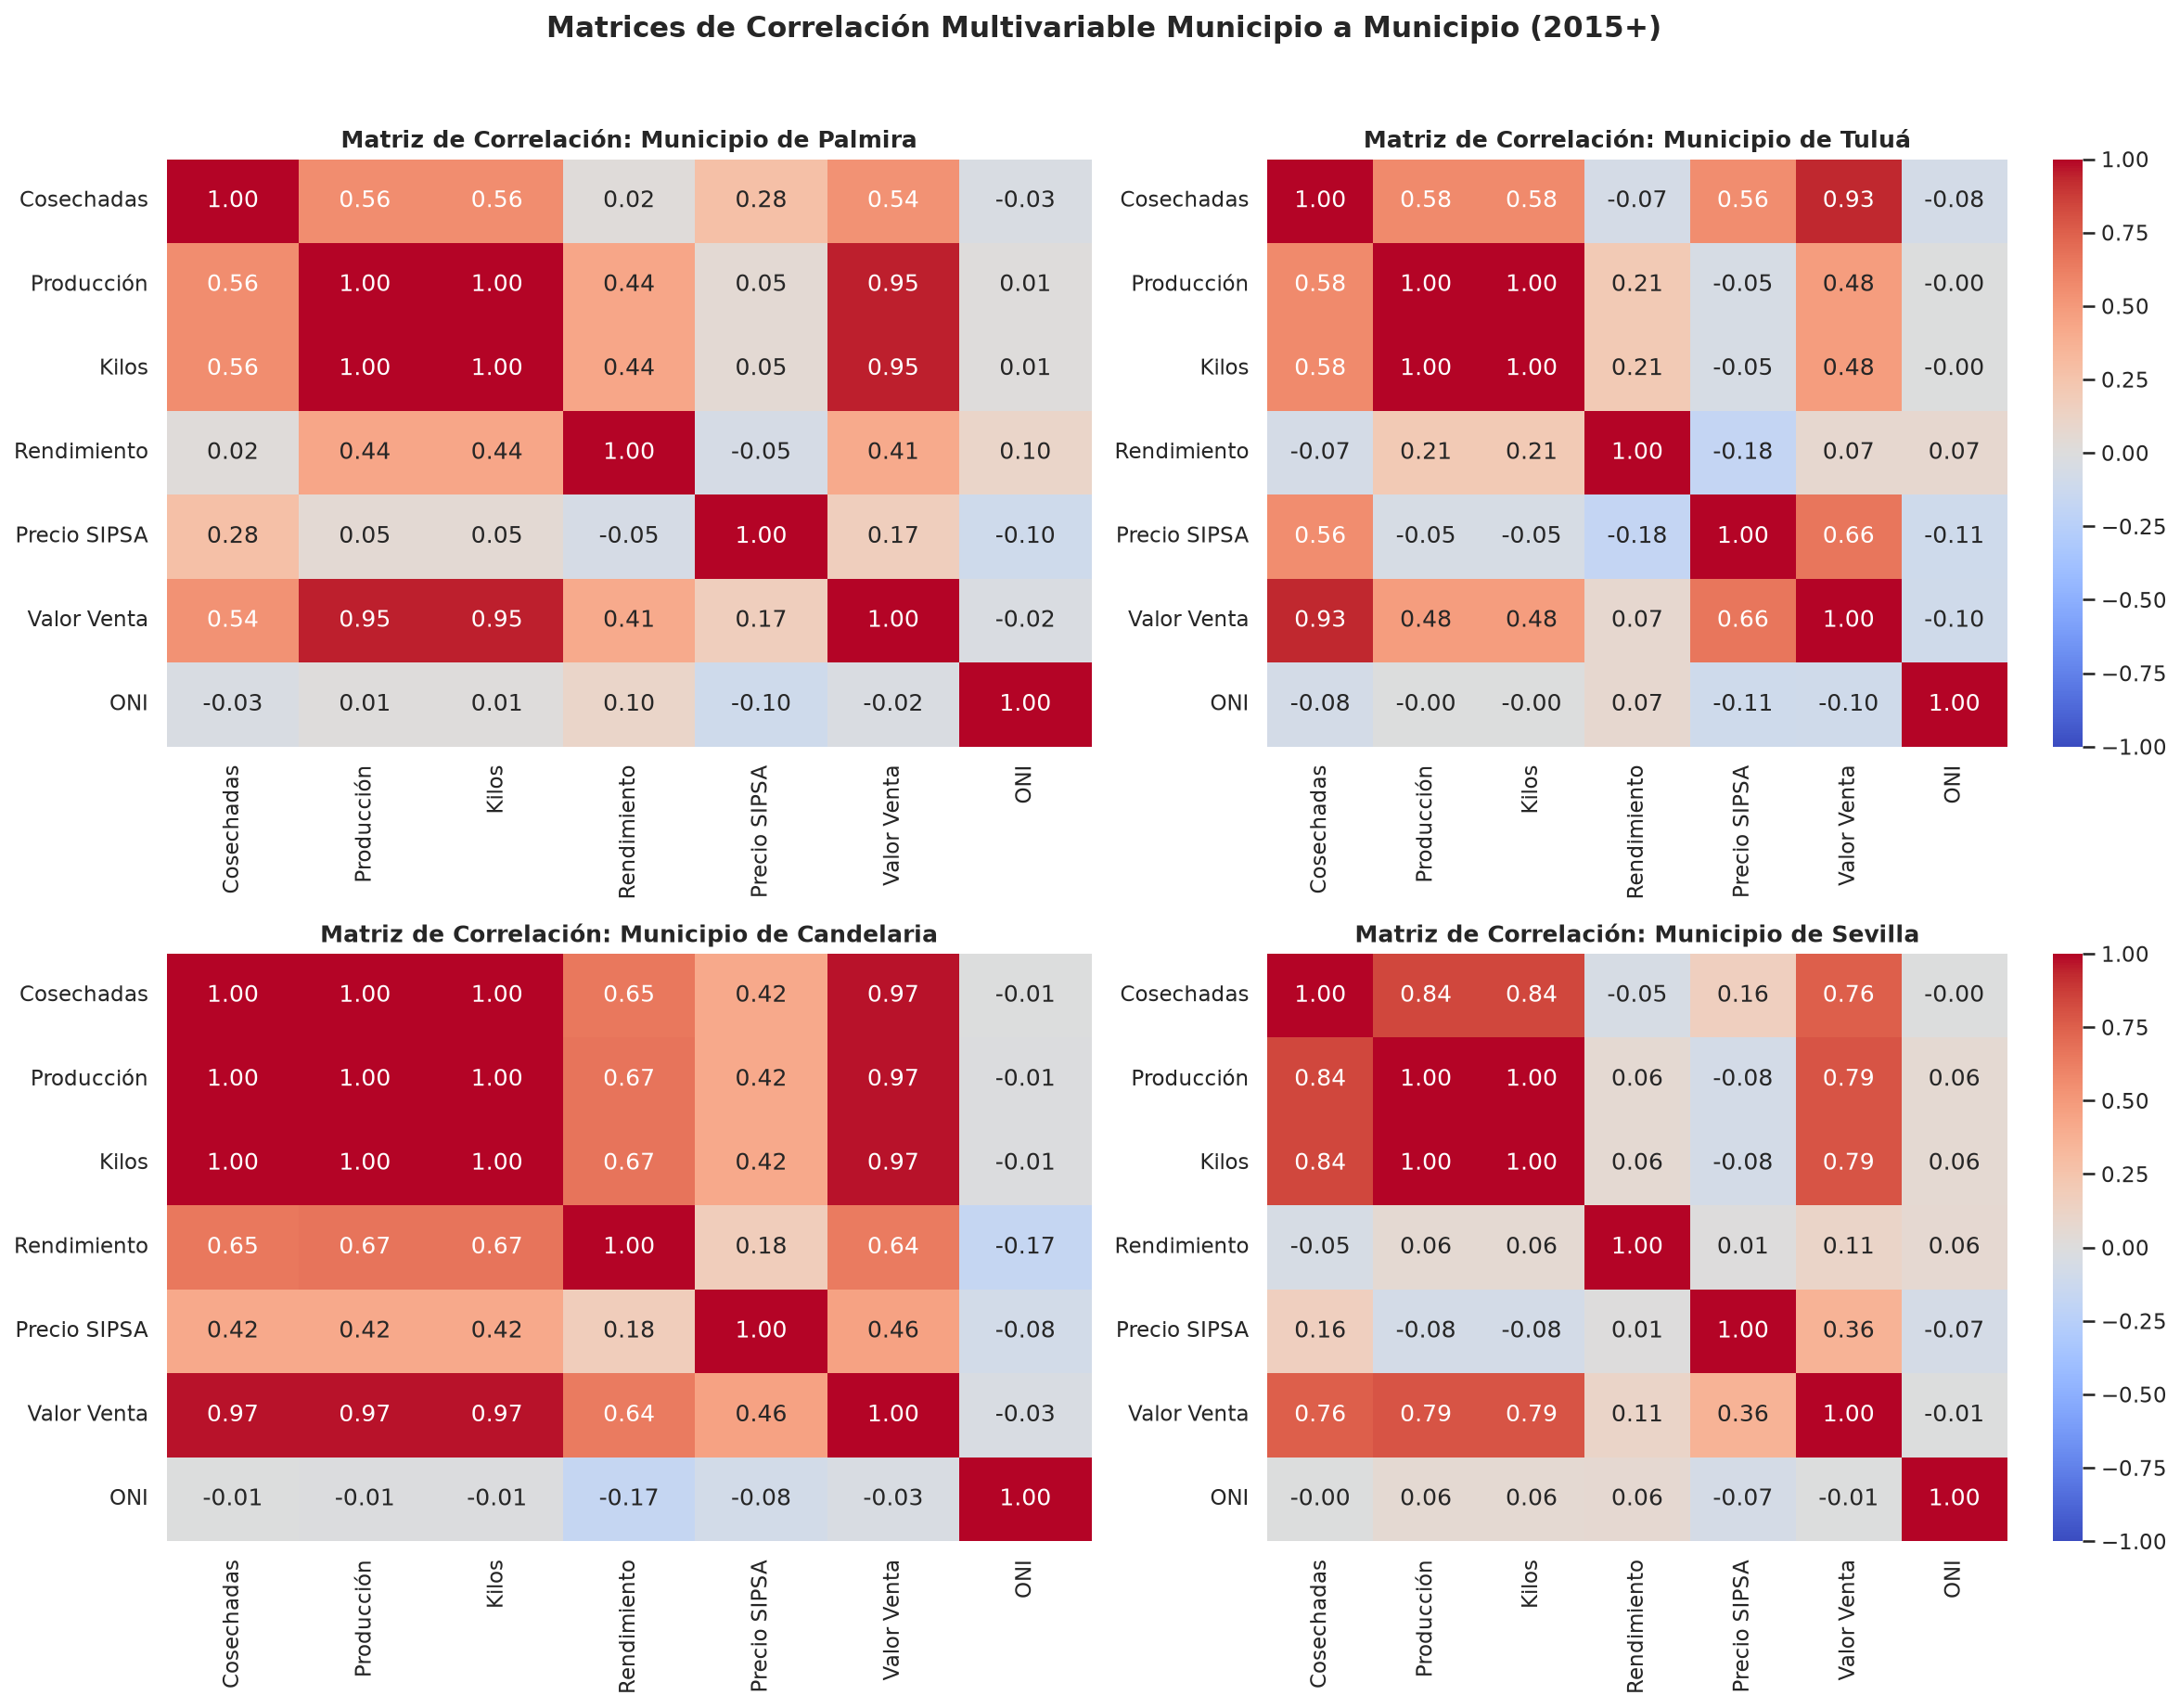

In [1]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
cols_corr = ['hectareas_cosechadas', 'produccion_toneladas', 'kilos_cosechados', 'rendimiento_toneladas_ha', 'precio_promedio_anual_sipsa', 'valor_venta_millones', 'promedio_oni']
nombres_corr = ['Cosechadas', 'Producción', 'Kilos', 'Rendimiento', 'Precio SIPSA', 'Valor Venta', 'ONI']
muns_matriz = ['Palmira', 'Tuluá', 'Candelaria', 'Sevilla']
for idx, mun in enumerate(muns_matriz):
    df_m = df[df['municipio'] == mun][cols_corr].dropna()
    sns.heatmap(df_m.corr(), ax=axes[idx], annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, xticklabels=nombres_corr, yticklabels=nombres_corr, cbar=(idx%2==1))
    axes[idx].set_title(f'Matriz de Correlación: Municipio de {mun}', fontsize=12, fontweight='bold')
plt.suptitle('Matrices de Correlación Multivariable Municipio a Municipio', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Conclusiones y Resumen del EDA Municipio a Municipio por Cultivo (2015-2024)

### Q&A
- **¿Por qué la visualización municipio a municipio analizando sus varios cultivos resolvió la interpretación agronómica?**  
  Cada municipio del Valle del Cauca posee condiciones geográficas y de suelo distintas. Al estructurar el estudio **municipio a municipio** y graficar dentro de cada territorio sus varios cultivos en subplots independientes, se aprecia claramente cómo en **Tuluá** conviven el Tomate y la Habichuela con precios estables, mientras en **Sevilla** predomina el Plátano y el Café, y en **Candelaria** la Caña panelera.
- **¿Qué revelan los diagramas por municipio sobre el rendimiento y precios SIPSA?**  
  En municipios de ladera (ej. Tuluá, Sevilla, Dagua), los varios cultivos hortícolas y frutales muestran mayor volatilidad ante el clima ONI que los cultivos extensivos planos de Candelaria o Palmira.

### Data Analysis Key Findings
- **Enfoque Municipio a Municipio:** Todos los gráficos de dispersión y correlación utilizan subplots dedicados por municipio mostrando sus distintos cultivos (`hue='cultivo'`).
- **Depuración Agronómica:** Filtro $0 < \text{Rendimiento} \le 100\text{ Ton}/\text{Ha}$ aplicado homogéneamente.

### Insights or Next Steps
1. **Modelos Predictivos Regionales por Municipio:** Utilizar el dataset agrupado por municipio y cultivo (`data/eda_resumen_municipio_producto.csv`) para personalizar sugerencias agrícolas por municipio.